<a href="https://colab.research.google.com/github/Raffy0-1/DHC-ML-Task_2/blob/main/Predict_Future_Stock_Prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Libraries

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

Loading Data

In [2]:
# Loading Apple stock data (last 2 years)
stock = yf.download("AAPL", start="2022-01-01", end="2024-01-01")

print(stock.head())
print(stock.info())

/tmp/ipykernel_583/2995695005.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download("AAPL", start="2022-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2022-01-03  178.103668  178.955006  173.895967  174.013387  104487900
2022-01-04  175.843277  179.013745  175.275723  178.710401   99310400
2022-01-05  171.165817  176.303140  170.891828  175.755162   94537600
2022-01-06  168.308533  171.537711  167.956258  168.993506   96904000
2022-01-07  168.474838  170.402559  167.359306  169.179387   86709100
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 501 entries, 2022-01-03 to 2023-12-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   501 non-null    float64
 1   (High, AAPL)    501 non-null    float64
 2   (Low, AAPL)     501 non-null    float64
 3   (Open, AAPL)    501 non-null    float64
 4   (Volume, AAPL)  501 non-null    int64  
dt

Creating Target of Next day close

In [3]:
# target column
stock['Next_Close'] = stock['Close'].shift(-1)

# Droping last row (because it has NaN target)
stock = stock.dropna()

Selecting Features

In [4]:
features = ['Open', 'High', 'Low', 'Volume']
X = stock[features]
y = stock['Next_Close']

Train Test Split (Time series based)

In [5]:
split = int(len(stock) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

Training the linear regression model

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

Evaluating the model

In [7]:
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 1.8709645158399146
R2 Score: 0.9178384772655119


Plotting Actual vs Predicted

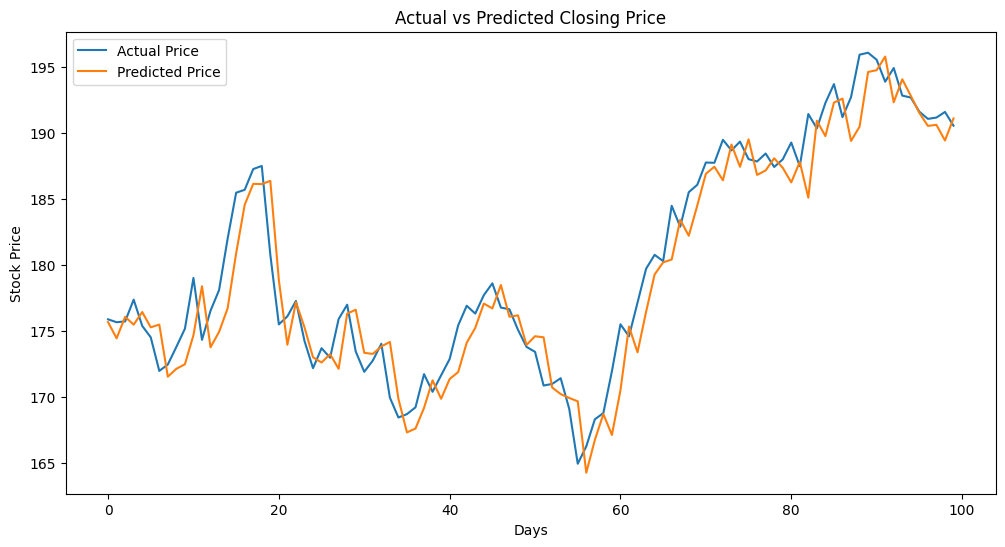

In [8]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.legend()
plt.title("Actual vs Predicted Closing Price")
plt.xlabel("Days")
plt.ylabel("Stock Price")
plt.show()

In [9]:
# rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
# rf_model.fit(X_train, y_train)

# rf_predictions = rf_model.predict(X_test)

# print("RF MAE:", mean_absolute_error(y_test, rf_predictions))
# print("RF R2:", r2_score(y_test, rf_predictions))

RF MAE: 2.1806062896728506
RF R2: 0.8837486172401197


i ain't using random forest refressor as my linear regression model performed better.